In [4]:
import numpy as np
import cv2
from scipy.ndimage import uniform_filter

def structure_ssim_map(img1, img2, window_size=11, c=1e-4):
    # Convert images to float32
    img1 = img1.astype(np.float32)
    img2 = img2.astype(np.float32)

    # Mean
    mu1 = uniform_filter(img1, window_size)
    mu2 = uniform_filter(img2, window_size)

    # Variance and covariance
    sigma1 = uniform_filter((img1 - mu1)**2, window_size)**0.5
    sigma2 = uniform_filter((img2 - mu2)**2, window_size)**0.5
    sigma12 = uniform_filter((img1 - mu1) * (img2 - mu2), window_size)

    # Structure component
    ssim_struct = (sigma12 + c) / (sigma1 * sigma2 + c)
    return ssim_struct


# def compute_metric()

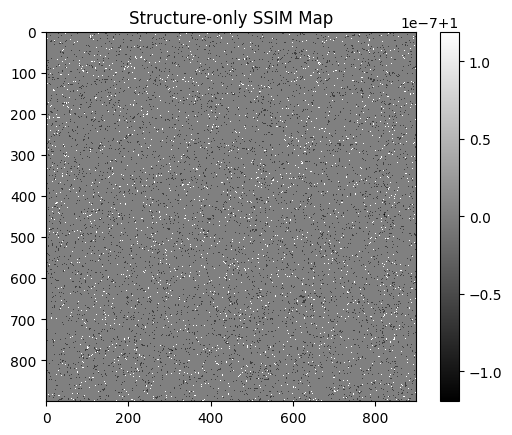

In [10]:
import cv2
# Read images (grayscale)
img1 = cv2.imread('images/SAMTest18/Bot_7_layer_0.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('images/SAMTest18/Bot_7_layer_0.png', cv2.IMREAD_GRAYSCALE)

ssim_struct_map = structure_ssim_map(img1, img2)

# Display or analyze the map
import matplotlib.pyplot as plt
plt.imshow(ssim_struct_map, cmap='gray')
plt.title("Structure-only SSIM Map")
plt.colorbar()
plt.show()


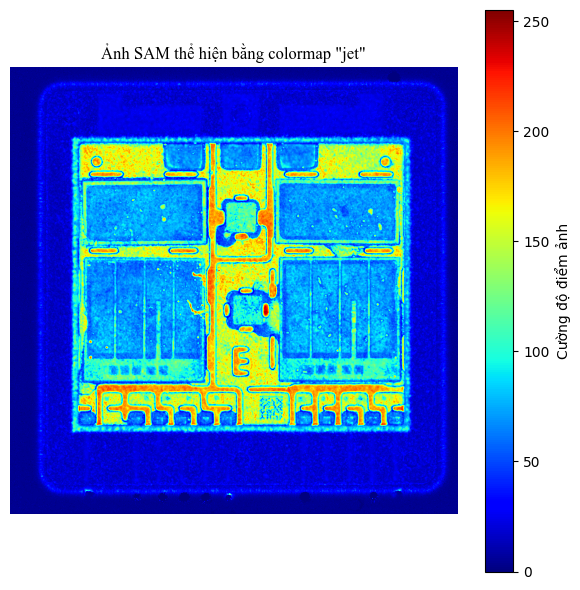

In [12]:
import cv2
import matplotlib.pyplot as plt

# Đọc ảnh grayscale
img = cv2.imread('images/SAMTest18/Bot_7_layer_0.png', cv2.IMREAD_GRAYSCALE)

# Hiển thị ảnh với colormap khác (ví dụ: 'jet', 'magma', 'plasma', 'viridis')
plt.figure(figsize=(6, 6))
plt.imshow(img, cmap='jet', vmin=0, vmax=255)
plt.title('Ảnh SAM thể hiện bằng colormap "jet"', fontname='Times New Roman')
plt.colorbar(label='Cường độ điểm ảnh')
plt.axis('off')
plt.tight_layout()
plt.savefig('bot7_colormap_jet.png', dpi=300)
plt.show()


In [6]:
import numpy as np
from skimage.metrics import structural_similarity as ssim

def calculate_image_quality_score(noisy_image, denoised_image):
    """
    Calculate the image quality score e between a noisy image and a denoised image.
    
    Args:
        noisy_image (numpy.ndarray): The noisy image (I)
        denoised_image (numpy.ndarray): The denoised image (Î_h)
        
    Returns:
        float: The image quality score e
    """
    # Ensure images are numpy arrays and have the same shape
    noisy_image = np.array(noisy_image, dtype=np.float32)
    denoised_image = np.array(denoised_image, dtype=np.float32)
    
    if noisy_image.shape != denoised_image.shape:
        raise ValueError("Noisy and denoised images must have the same shape")

    # Step 1: Compute MNI (Mean Noise Image)
    M_h = noisy_image - denoised_image
    
    
    # Step 2: Compute structure similarity map N between noisy image and MNI using SSIM (Eq. 3)
    # Use full=True to get the map, not just the score
    _, N = ssim(noisy_image, M_h, full=True, channel_axis=-1 if noisy_image.ndim == 3 else None, data_range=1.0)

    
    # Step 3: Compute structure similarity map P between noisy image and denoised image using SSIM (Eq. 4)
    _, P = ssim(noisy_image, denoised_image, full=True, channel_axis=-1 if noisy_image.ndim == 3 else None, data_range=1.0)

    
    # Step 4: Compute image quality score e as the linear correlation coefficient of N and P
    # Flatten the maps to 1D arrays for correlation
    N_flat = N.flatten()
    P_flat = P.flatten()
    
    # Debug: Print variances

    
    # Check for variance to avoid undefined correlation
    if np.var(N_flat) == 0 or np.var(P_flat) == 0:
        print("Warning: One of the SSIM maps has zero variance, correlation is undefined. Returning 0.")
        return 0.0
    
    # Compute Pearson correlation coefficient
    e = np.corrcoef(N_flat, P_flat)[0, 1]
    
    # If correlation is nan (due to numerical issues), return 0
    if np.isnan(e):
        print("Warning: Correlation resulted in NaN. Returning 0.")
        return 0.0
    
    return np.abs(e*100)

# import cv2
# if __name__ == "__main__":
#     # Load images in grayscale
#     img1 = cv2.imread('../../../Content/Chart/Fig/ImageDenoise/Noise/Bot_5_layer_7_x192_y448.png', cv2.IMREAD_GRAYSCALE)
#     img2 = cv2.imread('../../../Content/Chart/Fig/ImageDenoise/Denoise/Bot_5_layer_7_x192_y448.png', cv2.IMREAD_GRAYSCALE)
    
#     # Check if images are loaded successfully
#     if img1 is None or img2 is None:
#         raise FileNotFoundError("One or both images failed to load. Check the file paths.")
    
#     # Assume img1 is the noisy image and img2 is the denoised image
#     score = calculate_image_quality_score(img1, img2)
#     print(f"Image quality score: {score}")

In [3]:
import cv2
import numpy as np
from skimage import measure

def auto_select_rois(image, num_signal_rois=3, background_percentile=10, signal_percentile=90):
    """
    Auto-select background and signal ROIs based on intensity thresholds.
    
    Args:
        image (np.ndarray): grayscale image
        num_signal_rois (int): number of top bright regions to keep as signal
        background_percentile (int): threshold percentile for background (default 5%)
        signal_percentile (int): threshold percentile for signal (default 95%)
    
    Returns:
        signal_rois (list of np.ndarray), background_roi (np.ndarray)
    """
    # Flatten intensities
    flat = image.flatten()
    
    # Thresholds
    bg_thresh = np.percentile(flat, background_percentile)
    sig_thresh = np.percentile(flat, signal_percentile)
    
    # Background mask (dark region)
    bg_mask = image < bg_thresh
    background_roi = image[bg_mask]
    
    # Signal mask (bright region)
    sig_mask = image > sig_thresh
    
    # Connected components to isolate regions
    labels = measure.label(sig_mask, connectivity=2)
    props = measure.regionprops(labels, intensity_image=image)
    
    # Sort regions by mean intensity, take top N as signals
    props_sorted = sorted(props, key=lambda x: x.mean_intensity, reverse=True)[:num_signal_rois]
    signal_rois = [image[labels == p.label] for p in props_sorted]
    
    return signal_rois, background_roi


def calculate_snr_cnr(image, num_signal_rois=3):
    """
    Full pipeline: auto-select ROIs and compute SNR, CNR using correct formulas.
    """
    signal_rois, background_roi = auto_select_rois(image, num_signal_rois=num_signal_rois)
    
    # Background stats
    mu_b = np.mean(background_roi)
    sigma_b = np.std(background_roi)
    
    # Signal stats
    mu_signals = [np.mean(roi) for roi in signal_rois]
    sigma_signals = [np.std(roi) for roi in signal_rois]
    
    # --- SNR ---
    snr = 20 * np.log10(np.mean(mu_signals) / sigma_b)
    
    # --- CNR ---
    num = np.mean([abs(mu_i - mu_b) for mu_i in mu_signals])
    den = np.sqrt(np.mean([sigma_i**2 for sigma_i in sigma_signals]) + sigma_b**2)
    cnr = 20 * np.log10(num / den)
    
    return snr


# ===================== USAGE =====================
# Load grayscale images
img = cv2.imread("../../../Content/ResultImage/Unsupervised/UnsupervisedTest/InputModel/Bot_5_layer_7.png", cv2.IMREAD_GRAYSCALE)
img_denoise = cv2.imread("../../../Content/ResultImage/Unsupervised/UnsupervisedTest/OurModel/Bot_5_layer_7.png", cv2.IMREAD_GRAYSCALE)

snr = calculate_snr_cnr(img)
print(f"Noise:   SNR: {snr:.2f} dB")

snr = calculate_snr_cnr(img_denoise)
print(f"Denoise: SNR: {snr:.2f} dB")


Noise:   SNR: 25.72 dB
Denoise: SNR: 27.26 dB


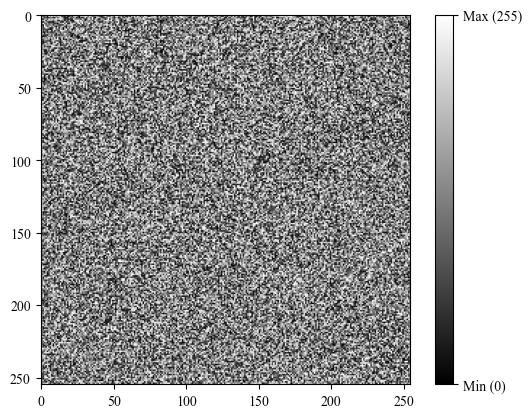

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Example image data
data = np.random.rand(255, 255)  # replace with your image
plt.rcParams['font.family'] = 'Times New Roman'

plt.imshow(data, cmap='gray')  # grayscale colormap
cbar = plt.colorbar(orientation='vertical')  # vertical colorbar
# cbar.set_label('Intensity', fontsize=12, fontweight='bold')

# Optionally, set ticks for min/max labels like your image
cbar.set_ticks([np.min(data), np.max(data)])
cbar.set_ticklabels(['Min (0)', 'Max (255)'])

plt.show()


In [32]:
from glob import glob
import os.path as osp
models = ['ADNet', 'Blur', 'BM3D', 'CBDNet', 'DNCNN', 'FDNCNN', 'InvDN', 'IRCNet', 'Restormer', 'SwinIR', 'OurModel\\Test_Image_Denoising-v7\\visualization\\SAMTest18']
model_scores = {
    'model':None,
    'score':None
}
for model in models:
    print(f"Processing model: {model}")
    scores = []
    for img_path in glob('D:\\nbmlab\\research\\paper\\resolution\\ImageDenoising\\Content\\ResultImage\\Unsupervised\\InputModel\\*_7.png'):
        img_noise = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if model in ['ADNet', 'InvDN']:
            img_denoised = cv2.imread(f'D:\\nbmlab\\research\\paper\\resolution\\ImageDenoising\\Content\\ResultImage\\Unsupervised\\{model}\\denoised_{osp.basename(img_path)}', cv2.IMREAD_GRAYSCALE) 
        elif model == 'BM3D':
            img_denoised = cv2.imread(f'D:\\nbmlab\\research\\paper\\resolution\\ImageDenoising\\Content\\ResultImage\\Unsupervised\\{model}\\basic_{osp.basename(img_path)}', cv2.IMREAD_GRAYSCALE) 
        elif model == 'SwinIR':
            img_denoised = cv2.imread(f'D:\\nbmlab\\research\\paper\\resolution\\ImageDenoising\\Content\\ResultImage\\Unsupervised\\{model}\\{osp.basename(img_path).split(".")[0]}_SwinIR.png', cv2.IMREAD_GRAYSCALE) 
        else:
            img_denoised = cv2.imread(f'D:\\nbmlab\\research\\paper\\resolution\\ImageDenoising\\Content\\ResultImage\\Unsupervised\\{model}\\{osp.basename(img_path)}', cv2.IMREAD_GRAYSCALE) 
            
        score = calculate_image_quality_score(img_noise, img_denoised)
        scores.append(score)
    
    model_scores['model'] = model
    model_scores['score'] = np.mean(scores)

    print("Average Quality Score:", np.mean(scores))

Processing model: ADNet
Average Quality Score: 2.6791638608469057
Processing model: Blur
Average Quality Score: 4.400225115196427
Processing model: BM3D
Average Quality Score: 45.302735765227794
Processing model: CBDNet
Average Quality Score: 44.26503330424359
Processing model: DNCNN
Average Quality Score: 8.041789932173158
Processing model: FDNCNN
Average Quality Score: 1.7995926088294179
Processing model: InvDN
Average Quality Score: 22.19422797281294
Processing model: IRCNet
Average Quality Score: 6.483386136142896
Processing model: Restormer
Average Quality Score: 11.002998787500665
Processing model: SwinIR
Average Quality Score: 9.483731778275825
Processing model: OurModel\Test_Image_Denoising-v7\visualization\SAMTest18
Average Quality Score: 23.624574775541845


In [9]:
import cv2
import numpy as np
import pandas as pd
from glob import glob
import os.path as osp


models = [
    'InputModel','ADNet', 'BM3D', 'Blur', 'CBDNet', 'DNCNN', 'FDNCNN',
    'FFDNet', 'IRCNet', 'InvDN', 'Restormer', 'SwinIR', 'Xformer', 'MambaIR', 'OurModel\\Metric'
]

input_dir = 'D:\\nbmlab\\research\\paper\\resolution\\ImageDenoising\\Content\\ResultImage\\Unsupervised\\UnsupervisedTest\\InputModel\\'
image_paths = sorted(glob(osp.join(input_dir, '*_7.png')))
image_names = [osp.basename(p) for p in image_paths]

# Create a DataFrame: rows = image names, columns = models
df = pd.DataFrame(index=[f'Image {i+1}' for i in range(len(image_names))], columns=models)

for model in models:
    print(f"Processing model: {model}")
    model_scores = []

    for i, img_path in enumerate(image_paths):
        img_name = osp.basename(img_path)
        img_noise = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        denoised_path = f'D:\\nbmlab\\research\\paper\\resolution\\ImageDenoising\\Content\\ResultImage\\Unsupervised\\UnsupervisedTest\\{model}\\{img_name}'
        img_denoised = cv2.imread(denoised_path, cv2.IMREAD_GRAYSCALE)

        if img_denoised is None:
            print(f"Warning: {denoised_path} not found!")
            score = np.nan
        else:
            score = calculate_image_quality_score(img_noise, img_denoised)
            print(score)

        df.loc[f'Image {i+1}', model] = score
        model_scores.append(score)

    # Compute average score per model
    df.loc['average', model] = np.nanmean(model_scores)

# Add "Metric" column
df.insert(0, 'Metric', df.index)

# Save to Excel
df.to_excel('denoising_scores_snr_2.xlsx', index=False)
print("Saved to 'denoising_scores_snr_2.xlsx'")

Processing model: InputModel
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
Processing model: ADNet
0.9675954199275314
2.23820773831071
1.8188091561211275
3.165802578167253
2.4182591140341048
4.119612012826887
2.725513890114686
3.0640381255449487
1.8408409948592934
3.7681749248238408
5.088158322813911
0.934954052618577
Processing model: BM3D
52.65987051779813
56.36644976951797
46.05374561088792
36.91798024408972
46.00745879628633
41.246608120794015
25.720759070746595
43.02169885013895
36.49265025749552
52.91251702323998
51.56352013115456
54.66957079058383
Processing model: Blur
5.6492675211555685
6.0807848055234865
3.4625084249149958
7.6715529578713735
1.1021030732232862
1.1018976254934505
1.2022900041636349
1.8488162940265687
2.579429590075583
0.3110426566218989
18.217607357894718
3.5754010713925637
Processing model: CBDNet
66.10000161253957
4.953272914819334
20.452876042006167
4.362326755966274
35.74625339731784
68.48462743023231
76.6814633843919
69.96479485789054
62.061180430855565

In [28]:
model_scores

{'model': 'OurModel\\Test_Image_Denoising-DomainTransfer\\visualization\\SAMTest18',
 'score': 68.7087404197362}

In [9]:
import numpy as np
import cv2

def calculate_stm(image):
    """
    Calculate the Standard Deviation to Mean ratio (STM) for a given image.

    Args:
        image (numpy.ndarray): Input image (grayscale or color).

    Returns:
        float: STM value (σ / μ).
    """
    # Ensure image is a NumPy array in float format
    image = np.array(image, dtype=np.float32)

    # If color image, convert to grayscale for noise metric
    if image.ndim == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    mean_val = np.mean(image)
    std_val = np.std(image)

    # Avoid division by zero if mean is 0
    if mean_val == 0:
        return 0.0

    stm = std_val / mean_val
    return stm

if __name__ == "__main__":
    # Load images
    noisy_img = cv2.imread('images/unsupervised/Bot_6_layer_7.png', cv2.IMREAD_GRAYSCALE)
    denoised_img = cv2.imread('images/visualization/SAMTest18/Bot_6_layer_7.png', cv2.IMREAD_GRAYSCALE)

    if noisy_img is None or denoised_img is None:
        raise FileNotFoundError("One or both images failed to load. Check the file paths.")

    # Compute STM for both noisy and denoised images
    stm_noisy = calculate_stm(noisy_img)
    stm_denoised = calculate_stm(denoised_img)

    print(f"STM (noisy image): {stm_noisy:.6f}")
    print(f"STM (denoised image): {stm_denoised:.6f}")
    print(f"STM reduction: {stm_noisy - stm_denoised:.6f}")


STM (noisy image): 0.823997
STM (denoised image): 0.861398
STM reduction: -0.037402
